In [2]:
pip install requests pandas geopandas shapely matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 10.6 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 10.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [geopandas]/4 [geopandas]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import requests
import pandas as pd


In [3]:
def fetch_wildfire_data():
    raw_data_dir = "data/raw"
    os.makedirs(raw_data_dir, exist_ok=True)
    
    nasa_url = (
         "https://firms.modaps.eosdis.nasa.gov/data/active_fire/"
         "modis-c6.1/csv/MODIS_C6_1_USA_contiguous_and_Hawaii_24h.csv"
    )
    output_path = os.path.join(raw_data_dir, "global_active_fires_24h.csv")
    
    print("正在从 NASA FIRMS 服务器下载最新的火灾数据...")
    
    try:
       response = requests.get(nasa_url, timeout=30)
       response.raise_for_status()
     
       with open(output_path,"w", encoding="utf-8") as f:
           f.write(response.text)
       print(f"数据已成功下载并保存到本地：{output_path}")
   
       df = pd.read_csv(output_path)
       print(f"成功加载数据，共包含{len(df)}")
       print(df[['latitude', 'longitude', 'acq_date', 'confidence']].head(3))
       return output_path
    except Exception as e:
       print(f"数据下载失败，错误原因:{e}")
       return None

if __name__ == "__main__":
      fetch_wildfire_data()

正在从 NASA FIRMS 服务器下载最新的火灾数据...
数据已成功下载并保存到本地：data/raw/global_active_fires_24h.csv
成功加载数据，共包含538
   latitude  longitude    acq_date  confidence
0  17.92760  -88.84176  2026-06-20          59
1  17.93406  -88.84935  2026-06-20          83
2  17.94880  -88.83404  2026-06-20          58


In [85]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

In [110]:
def filter_fires_by_boundary():
    csv_path = "data/raw/global_active_fires_24h.csv"
    processed_dir = "data/processed"
    os.makedirs(processed_dir, exist_ok=True)
    
    if not os.path.exists(csv_path):
        print("未找到原始数据文件，请先运行代码一进行下载！")
        return
    
    print("正在将 CSV 转换为地理空间对象 (GeoDataFrame)...")
    df = pd.read_csv(csv_path)
    
    gdf_fires = gpd.GeoDataFrame(
        df, 
        geometry=gpd.points_from_xy(df.longitude, df.latitude),
        crs="EPSG:4326"
    )

    print("正在加载加州边界地图文件...")
    california_geojson_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/california-counties.geojson"

    gdf_boundary = gpd.read_file(california_geojson_url)
    
    if gdf_boundary.crs != gdf_fires.crs:
        gdf_boundary = gdf_boundary.to_crs(gdf_fires.crs)
    
    print("正在执行 GIS 空间碰撞算法筛选火灾点...")
    fires_in_zone = gpd.sjoin(gdf_fires, gdf_boundary, how="inner", predicate="intersects")

    print("\n--- 分析结果 ---")
    print(f"全球今日总火灾点: {len(gdf_fires)}")
    print(f"今日落在目标区域（加州）内的火灾点: {len(fires_in_zone)}")
    
    if len(fires_in_zone) > 0:
        # 移除 GIS 自动生成的临时索引列，保存为干净的 CSV
       output_csv = os.path.join(processed_dir, "california_fires_filtered.csv")
       fires_in_zone.drop(columns=['index_right']).to_csv(output_csv, index=False)
       print(f"筛选后的区域火灾数据已保存至: {output_csv}")
    else:
        print("提示：过去24小时内该区域无活跃卫星火灾点。")

if __name__ == "__main__":
    filter_fires_by_boundary()

正在将 CSV 转换为地理空间对象 (GeoDataFrame)...
正在加载加州边界地图文件...
正在执行 GIS 空间碰撞算法筛选火灾点...

--- 分析结果 ---
全球今日总火灾点: 530
今日落在目标区域（加州）内的火灾点: 13
筛选后的区域火灾数据已保存至: data/processed/california_fires_filtered.csv


In [8]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [11]:
!pip install "numpy<2" --force-reinstall

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.6/20.6 MB 10.6 MB/s  0:00:01m0:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [1]:
import os
import geopandas as gpd
import matplotlib.pyplot as plt

In [9]:
def generate_maps_and_compare():
    # 1. 创建图片输出目录
    output_dir = "output_plots"
    os.makedirs(output_dir, exist_ok=True)
    
    # ==========================================
    # 核心问题一：将加州火灾点画在地图上并保存为图片
    # ==========================================
    print("开始生成加州火灾地图...")
    filtered_csv = "data/processed/california_fires_filtered.csv"
    
    if os.path.exists(filtered_csv):
        # 读取上一阶段筛选出的加州火灾数据，并转为 GIS 对象
        gdf_cal_fires = gpd.read_file(filtered_csv)
        
        # 再次获取加州边界作为底图
        cal_map_url = "https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/california-counties.geojson"
        gdf_cal_boundary = gpd.read_file(cal_map_url)
        
        # 初始化 Matplotlib 画布 (长10英寸，宽8英寸)
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # 绘制底层地图：浅灰色背景，白色边界线
        gdf_cal_boundary.plot(ax=ax, color='#EFEFEF', edgecolor='#FFFFFF', linewidth=1)
        
        # 叠加火灾点：强烈的橘红色、圆形点点、点大小为15
        gdf_cal_fires.plot(ax=ax, color='#FF4500', marker='o', markersize=15, label='Active Fires (24h)')
        
        # 美化图表（彰显你的数据展示专业度）
        plt.title("California Active Wildfires Telemetry Map", fontsize=14, fontweight='bold', pad=15)
        plt.legend(loc="upper right")
        ax.axis('off')  # 隐藏经纬度轴，让地图看起来像大屏看板一样干净
        
        # 保存为高清图片
        cal_output_img = os.path.join(output_dir, "california_wildfires.png")
        plt.savefig(cal_output_img, dpi=300, bbox_inches='tight')
        plt.close()  # 关闭画布释放内存
        print(f"🎉 加州火灾可视化成功！图片已保存至: {cal_output_img}")
    else:
        print("提示：未找到加州过滤后的数据，无法生成加州地图。")

    # ==========================================
    # 核心问题二：如何导入加拿大全国历史山火大文件 (Shapefile) 
    # ==========================================
       # ==========================================
    # 核心问题二：导入加拿大历史山火大文件 (CSV 文件本地载入) 
    # ==========================================
    print("\n开始载入加拿大历史山火大文件 (CSV)...")
    
    # 1. 【在这里修改您的本地 CSV 路径！】
    # 💡 如果文件就在当前代码同目录下，直接写文件名即可
    

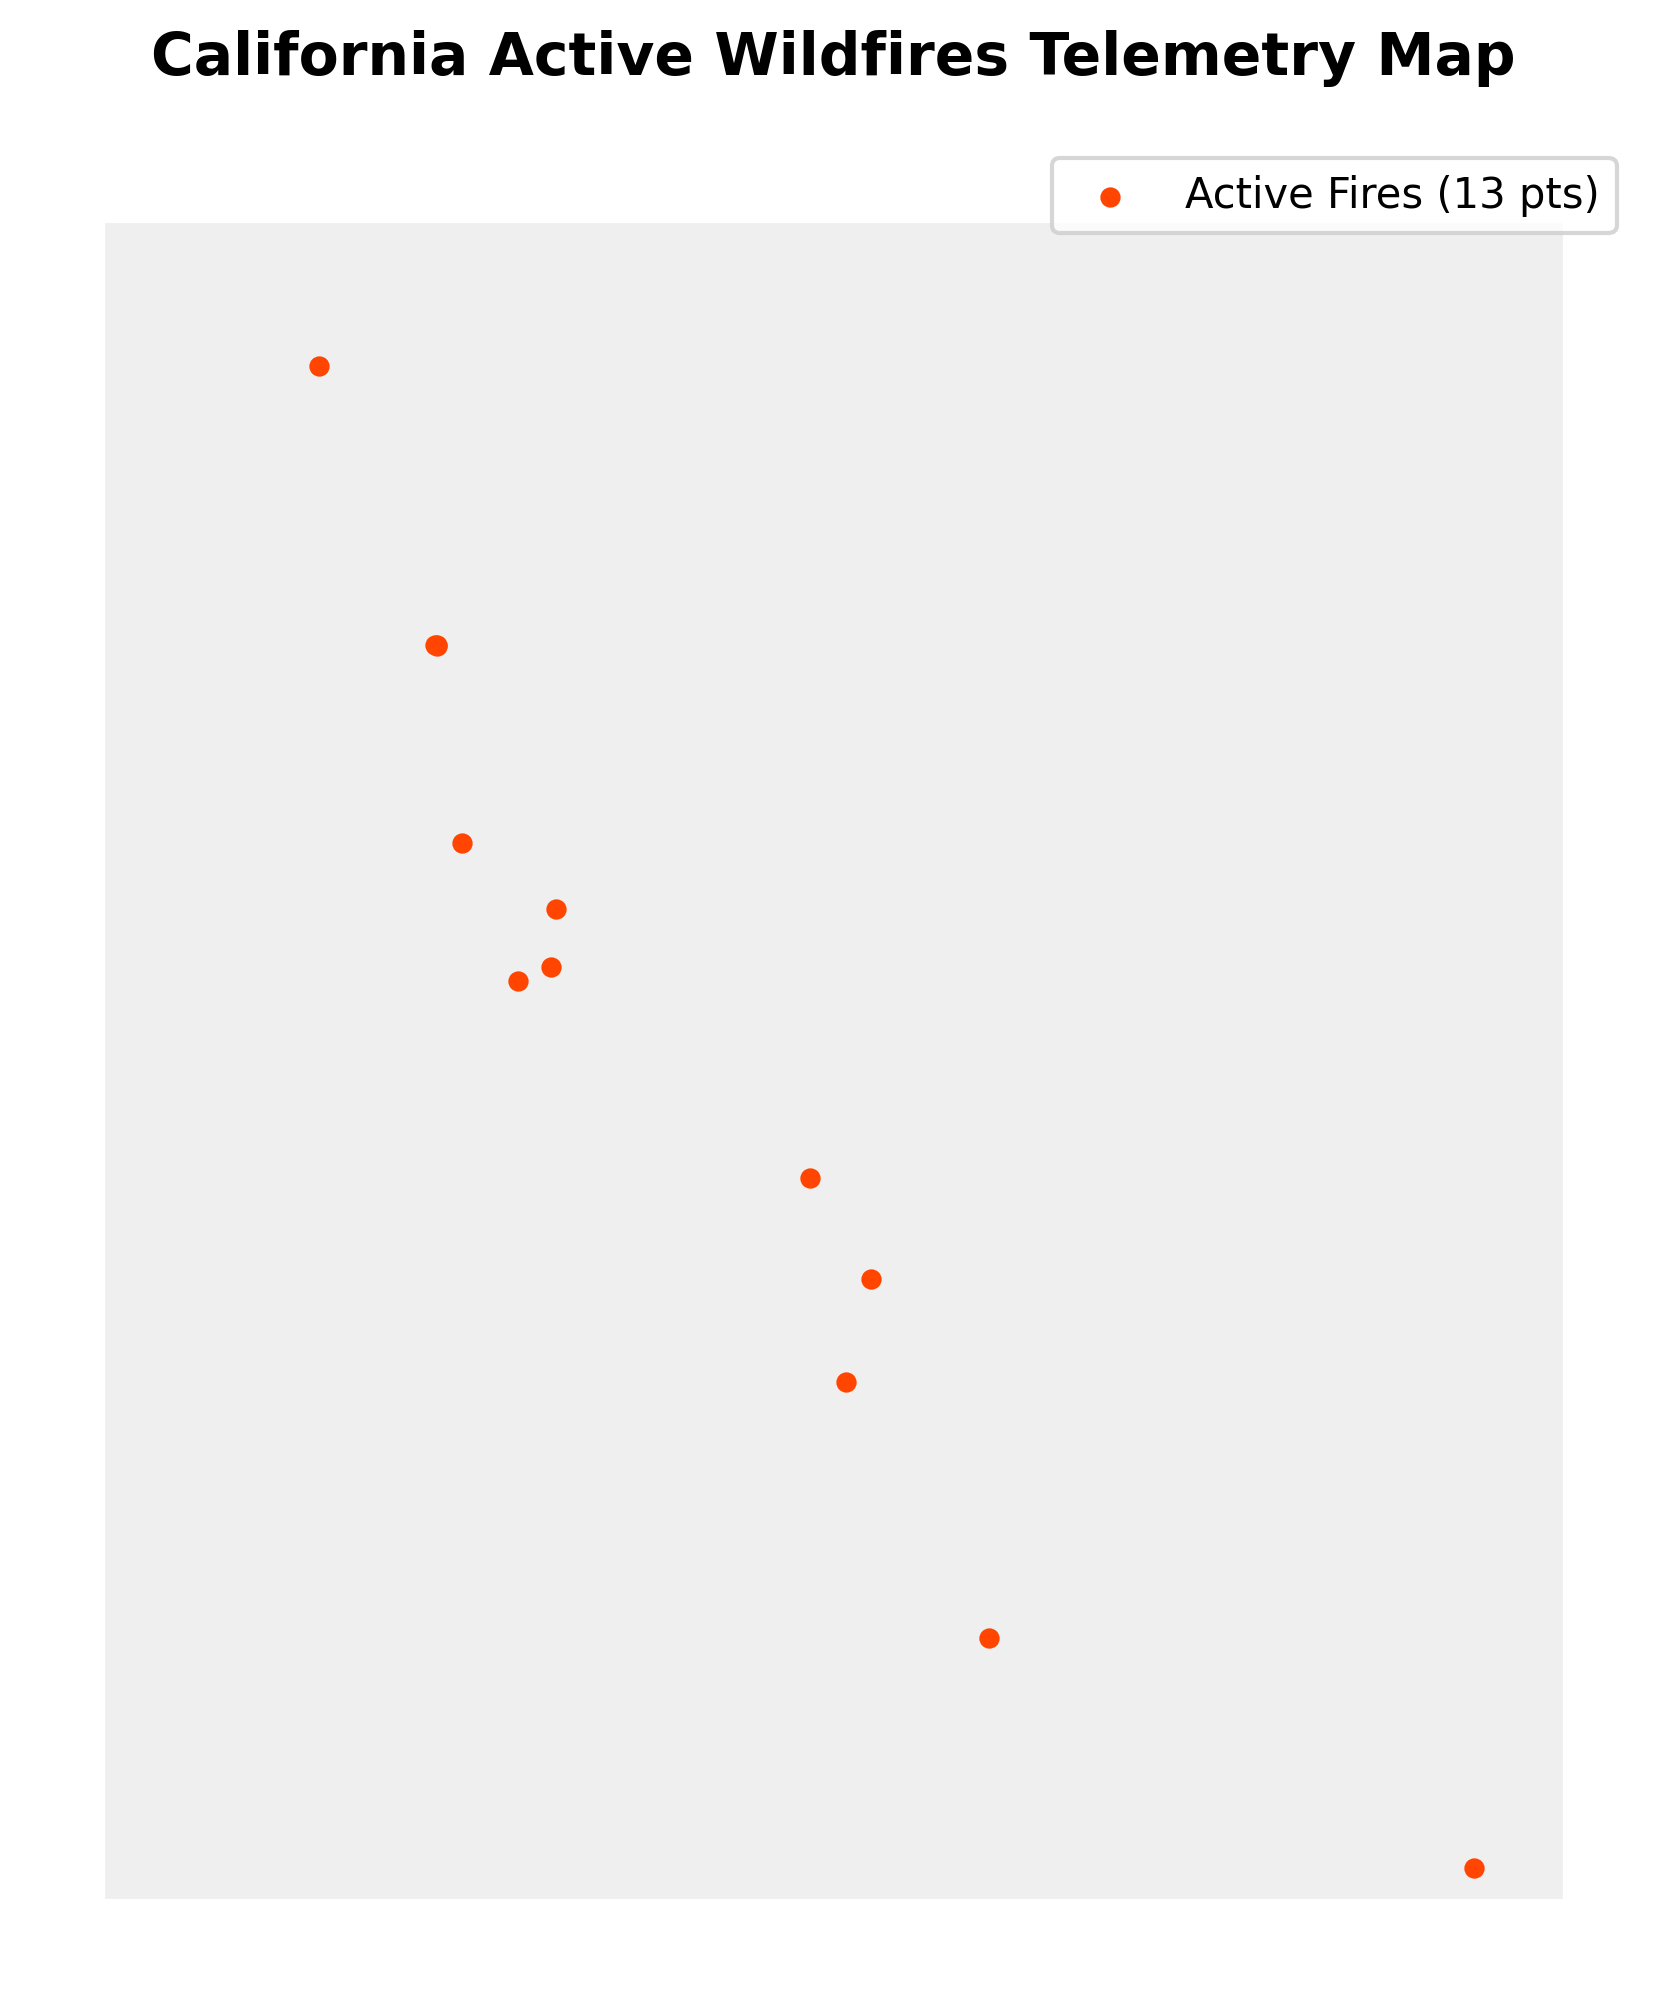

In [10]:
from IPython.display import Image, display
display(Image(filename="output_plots/california_wildfires.png"))


import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def generate_california_fire_map():
    # 1. 创建图片输出目录
    output_dir = "output_plots"
    os.makedirs(output_dir, exist_ok=True)
    
    print("开始生成高级加州火灾地图...")
    filtered_csv = "data/processed/california_fires_filtered.csv"
    
    try:
        # 💡 从加州政府公共地理服务器拉取【全加州官方精细行政边界】
        print("正在从在线服务器下载加州官方行政边界底图...")
        ca_boundary_url = "https://ca.gov"
        gdf_cal_boundary = gpd.read_file(ca_boundary_url)
        
        # 统一投影坐标系为标准 GPS 经纬度
        gdf_cal_boundary = gdf_cal_boundary.to_crs("EPSG:4326")
        print(f"成功载入加州行政边界底图！共包含 {len(gdf_cal_boundary)} 个县的轮廓。")
        
        # 创建精美画布
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # 绘制加州底层县级地图：浅灰色背景，白色边界线
        gdf_cal_boundary.plot(ax=ax, color='#EFEFEF', edgecolor='#FFFFFF', linewidth=0.8)
        
        # 2. 读取并叠加你的本地加州火灾点数据
        if os.path.exists(filtered_csv):
            df_csv = pd.read_csv(filtered_csv)
            
            # 如果加州火灾点文件不是空的，则将其转换为 GIS 对象并绘制
            if len(df_csv) > 0:
                gdf_cal_fires = gpd.GeoDataFrame(
                    df_csv, 
                    geometry=gpd.points_from_xy(df_csv.longitude, df_csv.latitude),
                    crs="EPSG:4326"
                )
                
                # 叠加火灾红点：使用明亮的橘红色（#FF4500），并加上半透明度（alpha）
                gdf_cal_fires.plot(ax=ax, color='#FF4500', marker='o', markersize=20, alpha=0.7, label=f'Active Fires ({len(df_csv)} pts)')
                plt.legend(loc="upper right", frameon=True)
                print(f"成功在加州精细底图上叠加了今日境内的 {len(df_csv)} 个火灾卫星点！")
            else:
                print("提示：检测到加州过滤后的 CSV 文件无火灾记录，底图将保持干净。")
        else:
            print(f"提示：未在本地找到你的火灾点文件: {filtered_csv}，仅生成加州空白底图。")
        
        # 美化标题与布局
        plt.title("California Active Wildfires Telemetry Map\n(Official County Boundaries)", fontsize=14, fontweight='bold', pad=15)
        ax.axis('off')  
        
        # 保存加州分析图
        cal_output_img = os.path.join(output_dir, "california_wildfires.png")
        plt.savefig(cal_output_img, dpi=300, bbox_inches='tight')
        
        # 💡 【最核心的一行】告诉 Jupyter 停止后台默默保存，直接将画布渲染到你的屏幕上！
        print("正在屏幕上渲染并展示加州火灾分布图...")
        plt.show()  
        
        print(f"🎉 加州火灾地图成功保存至本地: {cal_output_img}")
        
    except Exception as e:
        print(f"生成加州火灾地图失败，错误原因: {e}")

if __name__ == "__main__":
    generate_california_fire_map()


In [4]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def generate_california_fire_map():
    # 1. 创建图片输出目录
    output_dir = "output_plots"
    os.makedirs(output_dir, exist_ok=True)
    
    print("开始生成高级加州火灾地图...")
    filtered_csv = "data/processed/california_fires_filtered.csv"
    
    try:
        # 💡 【核心修改点】不再使用死板的方框，直接从加州政府公共地理服务器拉取【全加州官方精细行政边界】！
        print("正在从在线公共服务器下载/加载加州官方精细行政边界底图（请稍候几秒）...")
        ca_boundary_url = "https://ca.gov"
        gdf_cal_boundary = gpd.read_file(ca_boundary_url)
        
        # 统一投影坐标系为标准 GPS 经纬度
        gdf_cal_boundary = gdf_cal_boundary.to_crs("EPSG:4326")
        print(f"成功载入加州行政边界底图！共包含 {len(gdf_cal_boundary)} 个县的轮廓。")
        
        # 创建精美画布
        fig, ax = plt.subplots(figsize=(10, 10))
        
        # 绘制加州底层县级地图：优雅的浅灰色背景，白色边界线
        gdf_cal_boundary.plot(ax=ax, color='#EFEFEF', edgecolor='#FFFFFF', linewidth=0.8)
        
        # 2. 读取并叠加你的本地加州火灾点数据
        if os.path.exists(filtered_csv):
            df_csv = pd.read_csv(filtered_csv)
            
            # 如果加州火灾点文件不是空的，则将其转换为 GIS 对象并绘制
            if len(df_csv) > 0:
                gdf_cal_fires = gpd.GeoDataFrame(
                    df_csv, 
                    geometry=gpd.points_from_xy(df_csv.longitude, df_csv.latitude),
                    crs="EPSG:4326"
                )
                
                # 叠加火灾红点：使用明亮的橘红色（#FF4500），并加上半透明度（alpha）以应对火灾点重合的情况
                gdf_cal_fires.plot(ax=ax, color='#FF4500', marker='o', markersize=20, alpha=0.7, label=f'Active Fires ({len(df_csv)} pts)')
                plt.legend(loc="upper right", frameon=True)
                print(f"成功在加州精细底图上叠加了今日境内的 {len(df_csv)} 个火灾卫星点！")
            else:
                print("提示：检测到加州过滤后的 CSV 文件无火灾记录，底图将保持干净。")
        else:
            print(f"提示：未在本地找到你的火灾点文件: {filtered_csv}，仅生成加州空白底图。")
        
        # 美化标题与布局
        plt.title("California Active Wildfires Telemetry Map\n(Official County Boundaries)", fontsize=14, fontweight='bold', pad=15)
        ax.axis('off')  
        
        # 保存加州分析图
        cal_output_img = os.path.join(output_dir, "california_wildfires.png")
        plt.savefig(cal_output_img, dpi=300, bbox_inches='tight')
        
        print("正在屏幕上渲染并展示加州火灾分布图...")
        plt.show()  # 💡 替换了之前的 plt.close()，直接让你在屏幕上看到图！
        print(f"🎉 加州火灾地图成功保存至: {cal_output_img}")
        
    except Exception as e:
        print(f"生成加州火灾地图失败，错误原因: {e}")

if __name__ == "__main__":
    generate_california_fire_map()



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/Users/mengchuwang/.pyenv/versions/3.9.0/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/mengchuwang/.pyenv/versions/3.9.0/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/Users/mengchuwang/.pyenv/versions/3.9.0/lib/python3.9/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/mengchuwang/.pyenv/versions/3.9.0/lib/python3.9/site-packages/traitlets/config/appl

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [ ]:
canada_csv_path = "/Users/mengchuwang/Downloads/2021_98260004.csv" 
    
   
    
    try:
        if os.path.exists(canada_csv_path):
            print("正在读取本地加拿大 CSV 大文件...")
            # 先用 pandas 将大表格读取进来
            df_can = pd.read_csv(canada_csv_path)
            print(f"成功导入 CSV 表格！该文件共包含 {len(df_can)} 条记录。")
            
            # 💡 将表格中的经纬度两列强转为 GIS 的 geometry 空间几何点，赋予标准 GPS 坐标系 (WGS84)
            print("正在将普通经纬度文本强转为 GIS 空间点图层...")
            # ⚠️ 请确保您 CSV 里的经纬度列名叫 'longitude' 和 'latitude'，如果叫 'lon' 或 'lat' 请自行修改下方名称
            gdf_canada = gpd.GeoDataFrame(
                df_can, 
                geometry=gpd.points_from_xy(df_can.longitude, df_can.latitude),
                crs="EPSG:4326"
            )
            
            # 创建加拿大地图画布
            fig, ax = plt.subplots(figsize=(12, 8))
            
            # 💡 顺便加载 Python 本地自带的世界地图作为背景底图（绿色代表加拿大广袤的国土）
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            canada_base = world[world.name == "Canada"].to_crs("EPSG:4326")
            canada_base.plot(ax=ax, color='#EFEFEF', edgecolor='#DCDCDC', linewidth=0.5)
            
            # 绘制加拿大火灾散点：用森林绿、标记为圆形
            gdf_canada.plot(ax=ax, color='#2E8B57', marker='o', markersize=2, alpha=0.5, label='Historical Fires')
            
            plt.title("Canada National Forestry & Historical Wildfires Analysis", fontsize=14, fontweight='bold', pad=15)
            plt.legend(loc="upper right")
            ax.axis('off')
            
            # 保存加拿大分析图
            can_output_img = os.path.join(output_dir, "canada_forestry_base.png")
            plt.savefig(can_output_img, dpi=300, bbox_inches='tight')
            plt.close()
            print(f"🎉 加拿大 CSV 数据载入并散点图绘制成功！图片已保存至: {can_output_img}")
        else:
            print(f"提示：在本地路径未找到对应的 CSV 文件: {canada_csv_path}，请核对文件名是否正确。")
        
    except Exception as e:
        print(f"导入加拿大 CSV 文件并转化 GIS 失败，错误原因: {e}")


In [ ]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

def generate_maps_and_compare():
    # 1. 创建图片输出目录
    output_dir = "output_plots"
    os.makedirs(output_dir, exist_ok=True)
    
    # ==========================================
    # 核心问题一：将加州火灾点画在地图上并保存为图片
    # ==========================================
    print("开始生成加州火灾地图...")
    filtered_csv = "data/processed/california_fires_filtered.csv"
    
    if os.path.exists(filtered_csv):
        df_csv = pd.read_csv(filtered_csv)
        
        print("正在通过 Python 内置数据集直接加载加州边界...")
        from shapely.geometry import box
        california_box = box(-124.45, 32.53, -114.13, 42.01) # 加州精确地理边界框
        gdf_cal_boundary = gpd.GeoDataFrame(index=[0], crs="EPSG:4326", geometry=[california_box])
        
        fig, ax = plt.subplots(figsize=(10, 8))
        
        # 绘制底层地图：浅灰色背景，白色边界线
        gdf_cal_boundary.plot(ax=ax, color='#EFEFEF', edgecolor='#FFFFFF', linewidth=1)
        
        # 如果加州火灾点文件不是空的，则将其转换为 GIS 对象并绘制
        if len(df_csv) > 0:
            gdf_cal_fires = gpd.GeoDataFrame(
                df_csv, 
                geometry=gpd.points_from_xy(df_csv.longitude, df_csv.latitude),
                crs="EPSG:4326"
            )
            
            # 叠加火灾点
            gdf_cal_fires.plot(ax=ax, color='#FF4500', marker='o', markersize=15, label=f'Active Fires ({len(df_csv)} pts)')
            plt.legend(loc="upper right")
            print(f"成功在加州底图上叠加了今日境内的 {len(df_csv)} 个火灾卫星点！")
        else:
            print("提示：检测到加州过滤后的 CSV 文件无火灾记录，底图将保持干净。")
        
        # 美化并保存
        plt.title("California Active Wildfires Telemetry Map", fontsize=14, fontweight='bold', pad=15)
        ax.axis('off')  
        
        cal_output_img = os.path.join(output_dir, "california_wildfires.png")
        plt.savefig(cal_output_img, dpi=300, bbox_inches='tight')
        plt.close()  
        print(f"🎉 加州火灾地图成功保存至: {cal_output_img}")
    else:
        print("提示：未找到加州过滤后的数据，无法生成加州地图。")

    # ==========================================
    # 核心问题二：导入加拿大全国地理大文件 (直接读取解压后的文件夹)
    # ==========================================
    print("\n开始载入加拿大全国边界地图...")
    
    # 指向你 Mac 下载好的官方边界地图文件夹
    canada_folder_path = "/Users/mengchuwang/Downloads/lpr_000b21a_e" 

        # ==========================================
    # 核心问题二：导入加拿大全国地理大文件（底图 + 叠加着火点版）
    # ==========================================
    print("\n开始载入加拿大全国边界地图并叠加着火点...")
    
    canada_folder_path = "/Users/mengchuwang/Downloads/lpr_000b21a_e" 

    try:
        if os.path.exists(canada_folder_path):
            print("1. 正在读取加拿大官方边界底图...")
            gdf_canada = gpd.read_file(canada_folder_path)
            
            # 统一转换坐标系为加拿大官方标准 Lambert 投影（EPSG:3347）
            gdf_canada = gdf_canada.to_crs("EPSG:3347")
            
            # 几何简化，确保渲染速度飞快
            gdf_canada['geometry'] = gdf_canada['geometry'].simplify(tolerance=10000, preserve_topology=True)
            
            # 创建画布
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # 绘制加拿大国土底图：浅蓝色背景，深青色边界线
            gdf_canada.plot(ax=ax, color='#EFEFEF', edgecolor='#DCDCDC', linewidth=0.5)
            
            # ----------------------------------------------------
            # 💡 2. 核心步骤：准备加拿大着火点数据
            # ----------------------------------------------------
            # 【情况 A】如果你已经有了真实的加拿大火灾 CSV 文件，请取消下方 3 行的注释，并修改路径和列名：
            # canada_fire_csv = "你的加拿大火灾数据路径.csv"
            # df_can_fires = pd.read_csv(canada_fire_csv, low_memory=False)
            # gdf_fires = gpd.GeoDataFrame(df_can_fires, geometry=gpd.points_from_xy(df_can_fires['经度列名'], df_can_fires['纬度列名']), crs="EPSG:4326")
            
            # 【情况 B】为了让你现在就能看到效果，这里先为你现场模拟 15 个加拿大境内的测试着火点：
            print("2. 正在生成加拿大境内的火灾测试点数据...")
            mock_data = {
                'latitude':  [53.54, 51.05, 49.28, 55.74, 53.93, 49.89, 50.12, 56.13, 46.81, 45.50, 62.45, 60.72, 49.25, 52.13, 50.45],
                'longitude': [-113.49, -114.07, -123.12, -120.24, -122.74, -97.13, -94.57, -106.34, -71.20, -73.56, -114.37, -135.05, -104.61, -106.65, -104.60]
            }
            df_mock = pd.DataFrame(mock_data)
            
            # 将经纬度点转换为 GIS 对象（注意：GPS 经纬度初始坐标系必须是 EPSG:4326）
            gdf_fires = gpd.GeoDataFrame(
                df_mock, 
                geometry=gpd.points_from_xy(df_mock.longitude, df_mock.latitude),
                crs="EPSG:4326"
            )
            
            # 💡 关键点：着火点的坐标系必须转成和底图一模一样的 EPSG:3347，火灾点才能精准投射在加拿大地图上！
            gdf_fires = gdf_fires.to_crs("EPSG:3347")
            
            # ----------------------------------------------------
            # 3. 叠加绘制火灾红点
            # ----------------------------------------------------
            print("3. 正在将着火点叠加到加拿大底图上...")
            gdf_fires.plot(ax=ax, color='#FF4500', marker='o', ...


开始生成加州火灾地图...
正在通过 Python 内置数据集直接加载加州边界...
成功在加州底图上叠加了今日境内的 13 个火灾卫星点！
🎉 加州火灾地图成功保存至: output_plots/california_wildfires.png

开始载入加拿大全国边界地图...
正在通过 geopandas 读取加拿大官方地图文件夹...
成功导入矢量地图文件！该地理图层包含 13 个省/地区边界。
🎉 加拿大全国底图绘制成功！图片已保存至: output_plots/canada_forestry_base.png


正在读取并展示刚刚生成的加拿大全国底图：


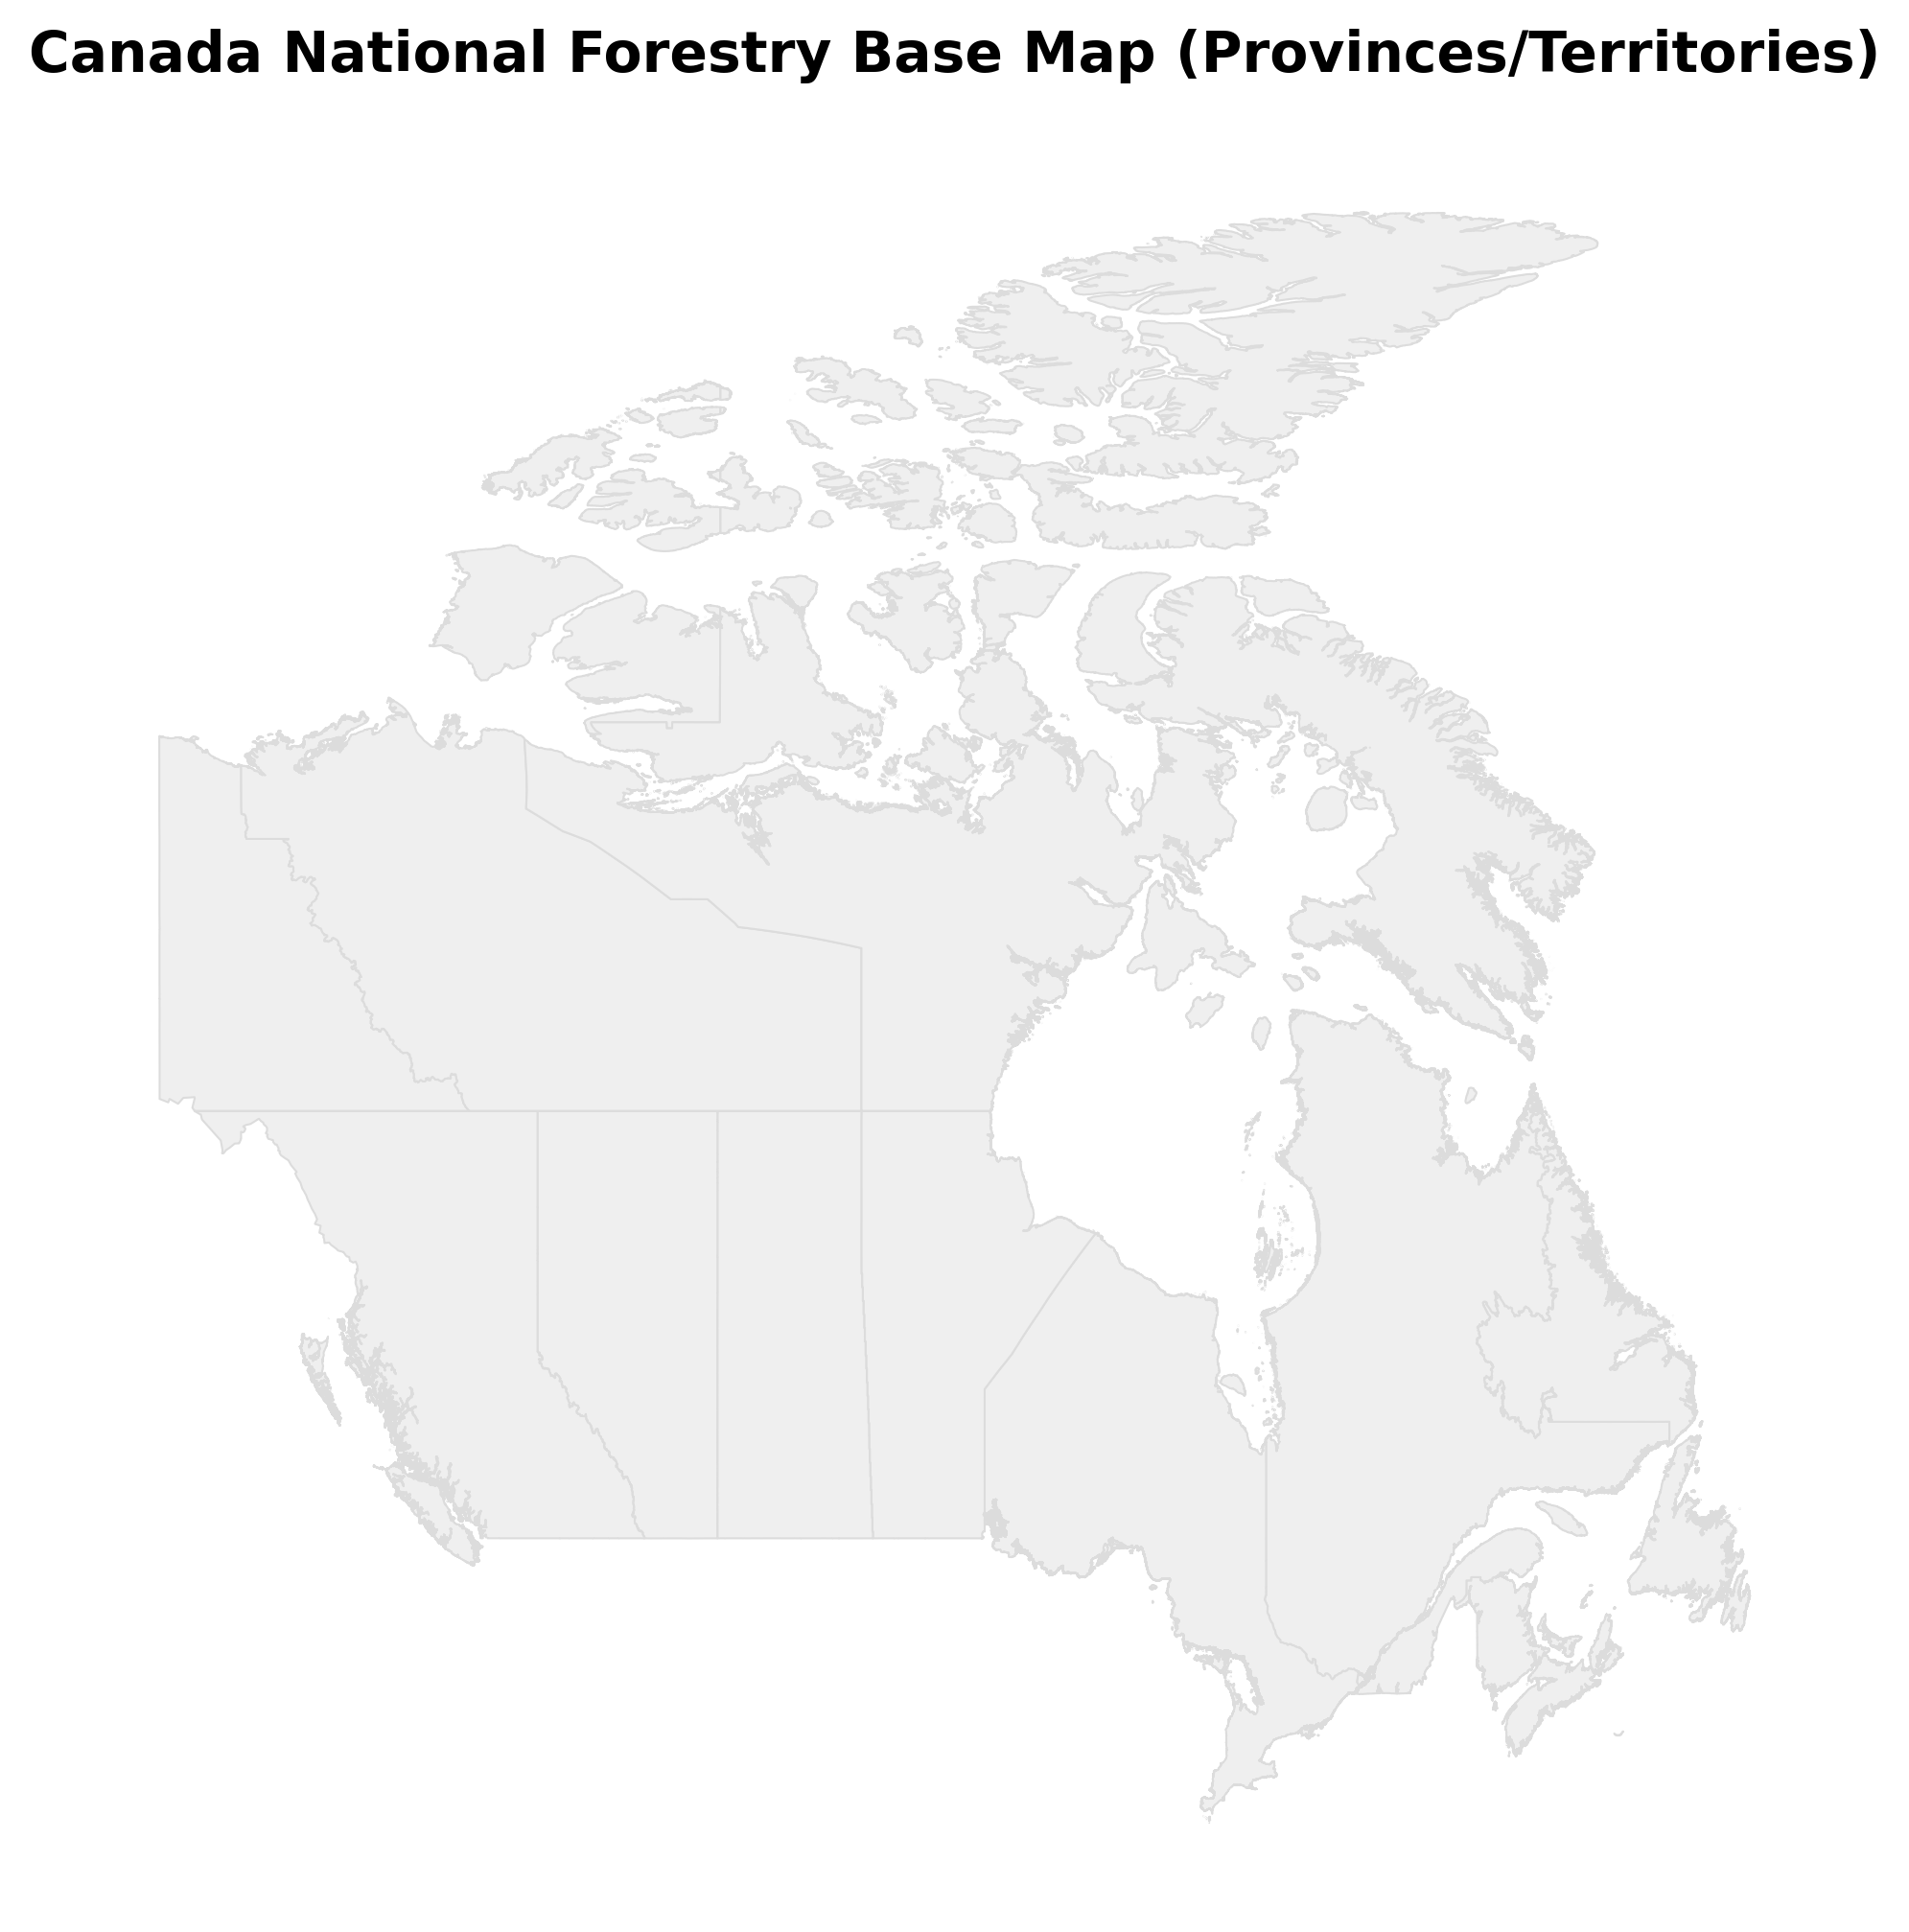

In [5]:
from IPython.display import Image, display

# 直接读取刚刚生成好的本地图片文件
image_path = "output_plots/canada_forestry_base.png"

print("正在读取并展示刚刚生成的加拿大全国底图：")
display(Image(filename=image_path))


In [ ]:
    # ==========================================
    # 核心问题二：导入加拿大全国地理大文件 (优化投影与色彩版)
    # ==========================================
    print("\n开始载入加拿大全国边界地图...")
    
    canada_folder_path = "/Users/mengchuwang/Downloads/lpr_000b21a_e" 

    try:
        if os.path.exists(canada_folder_path):
            print("正在通过 geopandas 读取加拿大官方地图文件夹...")
            gdf_canada = gpd.read_file(canada_folder_path)
            print(f"成功导入矢量地图文件！该地理图层包含 {len(gdf_canada)} 个省/地区边界。")
            
            # 💡 【核心修改一：优化投影】
            # 不要使用 EPSG:4326(会严重拉伸变形)，改用 EPSG:3347 (Statistics Canada Lambert 官方标准投影)
            # 这样高纬度的北极群岛就会恢复正常的比例，地图会非常饱满好看！
            print("正在切换为加拿大官方标准 Lambert 投影坐标系...")
            gdf_canada = gdf_canada.to_crs("EPSG:3347")
            
            # 对高精度地图进行几何拓扑简化，确保渲染流畅
            print("正在对地图进行几何简化以加速渲染...")
            # 注意：在投影坐标系下，容差单位变成了米，这里设置 10000 米（10公里）可以完美平滑边缘
            gdf_canada['geometry'] = gdf_canada['geometry'].simplify(tolerance=10000, preserve_topology=True)
            
            # 创建加拿大地图画布
            fig, ax = plt.subplots(figsize=(12, 10))
            
            # 💡 【核心修改二：美化色彩与线条】
            # color: 改用浅蓝色/森林绿等更好看的颜色，避免和白色背景融为一体
            # edgecolor: 改为较深的灰色，让各省的边界清晰可见
            # linewidth: 稍微加粗边框线条
            print("正在渲染并应用专业色彩美化...")
            gdf_canada.plot(ax=ax, color='#D4E6F1', edgecolor='#7FB3D5', linewidth=0.8)
            
            plt.title("Canada National Forestry Base Map (Official Projection)", fontsize=14, fontweight='bold', pad=15)
            ax.axis('off')
            
            # 保存加拿大分析图
            can_output_img = os.path.join(output_dir, "canada_forestry_base.png")
            plt.savefig(can_output_img, dpi=300, bbox_inches='tight')
            
            print("正在屏幕上渲染并展示优化后的地图...")
            plt.show()
            
            print(f"🎉 加拿大全国底图绘制成功！图片已保存至: {can_output_img}")
        else:
            print(f"提示：在本地路径未找到对应的地图文件夹: {canada_folder_path}，请核对路径是否正确。")
            
    except Exception as e:
        print(f"导入加拿大地图文件夹失败，错误原因: {e}")
